In [45]:
from pathlib import Path
import pandas as pd
import numpy as np
import umap
import umap.plot
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.stream_3.gen_hdb_clus import GenerateHDBSCAN2
from src.stream_3.gen_umap_emb import GenerateUmapEmb2
from src.loading_data.load_data import get_master_clustering_input
from src.loading_data.data_catalogue import DataCatalogue
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
import seaborn as sns

In [46]:
df = get_master_clustering_input()
df_sampled = df.sample(n=20000, random_state=42)

Master data loaded with zero missing values.


In [47]:
dc = DataCatalogue()
dc.get_clustering_continuous()

['Age9', 'NSSEC5', 'Educ6', 'IMD10', 'Child4', 'Motiva_POP', 'motivd_POP']

In [48]:
dc.get_clustering_categoricals()

['Gend3', 'Disab2_POP', 'Eth7', 'WorkStat8', 'HHLiv9']

In [49]:
continuous = dc.get_clustering_continuous()
categorical = dc.get_clustering_categoricals()
emb_generator = GenerateUmapEmb2()
umap_instance = emb_generator.fit_fuzzy_umap(
    df = df_sampled, 
    avail_contins=continuous, 
    avail_cats=categorical, 
    continuous_neighbors = 5, 
    categorical_neighbors = 5,
    continuous_metric= 'euclidean',
    categorical_metric= 'jaccard',
    operator = '*'
    )

Save path found.
Continuous Shape: (20000, 7)
Categorical Shape: (20000, 29)


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is like

Finished fitting continuous....


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for jaccard distance metric; inverse_transform will be unavailable
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\sklearn\metrics\pairwise.py:2474: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\spectral.py:548: UserWarning: Spectral initialisation failed! The eigenvector solver
failed. This is likely due to too small an eigengap. Consider
adding some noise or jitter to your data.

Falling back to random initialisation!
  warn(
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\L

Finished fitting categorical...
Computing fuzzy set intersection...
Finished computing intersection...
UMAP fit complete!
Embedding saved to
 C:\Users\fergu\Documents\GitHub\london_sport2\src\stream_3\embeddings
CLASS_UMAP_conn_5_catn_5_conm_euclidean_catm_jaccard_multip.npy saved to: C:\Users\fergu\Documents\GitHub\london_sport2\src\stream_3\embeddings\classes\CLASS_UMAP_conn_5_catn_5_conm_euclidean_catm_jaccard_multip.npy


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

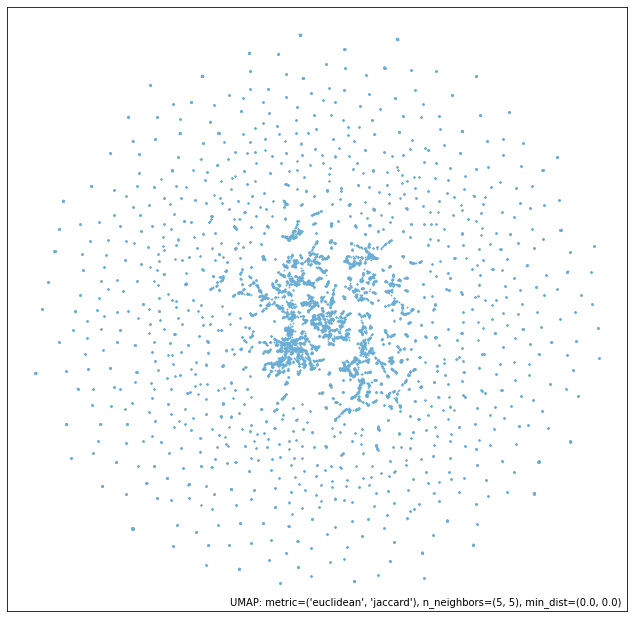

In [50]:
umap.plot.points(umap_instance)

In [51]:
plt.savefig('hehe.png')

<Figure size 432x288 with 0 Axes>

In [52]:
hdb = GenerateHDBSCAN2()
hdb.fit(umap_instance.embedding_)

 18%|█▊        | 2/11 [00:22<01:42, 11.40s/it]


KeyboardInterrupt: 

C:\Users\fergu\AppData\Local\Temp\ipykernel_43616\616345750.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


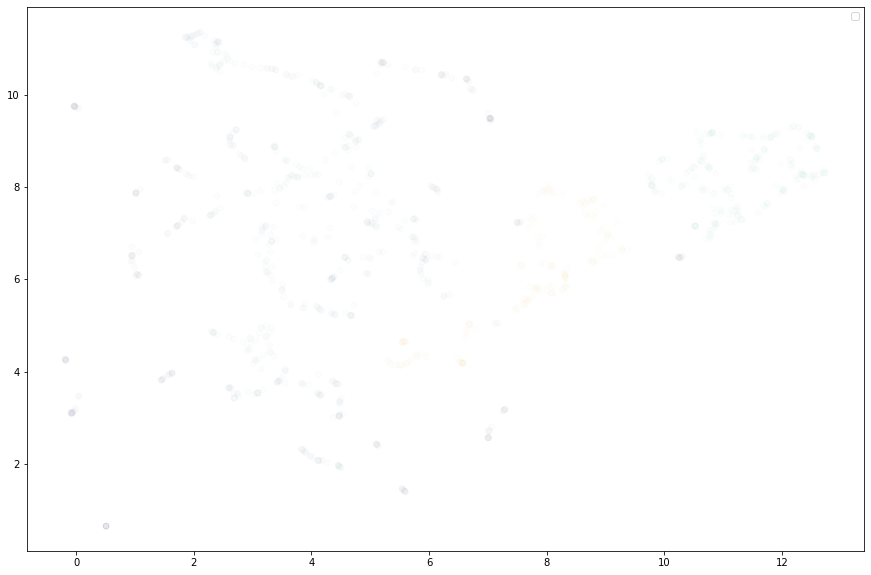

In [ ]:
plt.figure(figsize=(15,10))
plt.scatter(umap_instance.embedding_[:,0], umap_instance.embedding_[:,1], alpha=0.01, c=hdb.get_model().labels_)
plt.legend()

<Axes: >

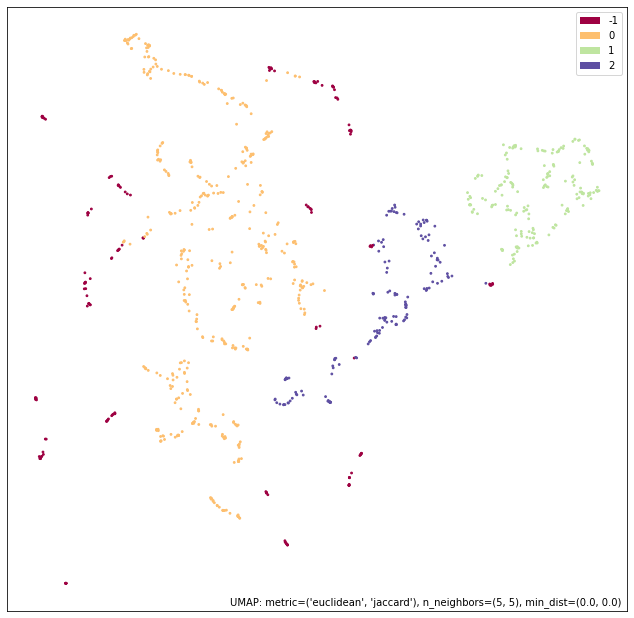

In [ ]:
umap.plot.points(umap_instance, labels = hdb.get_model().labels_)

<Axes: ylabel='$\\lambda$ value'>

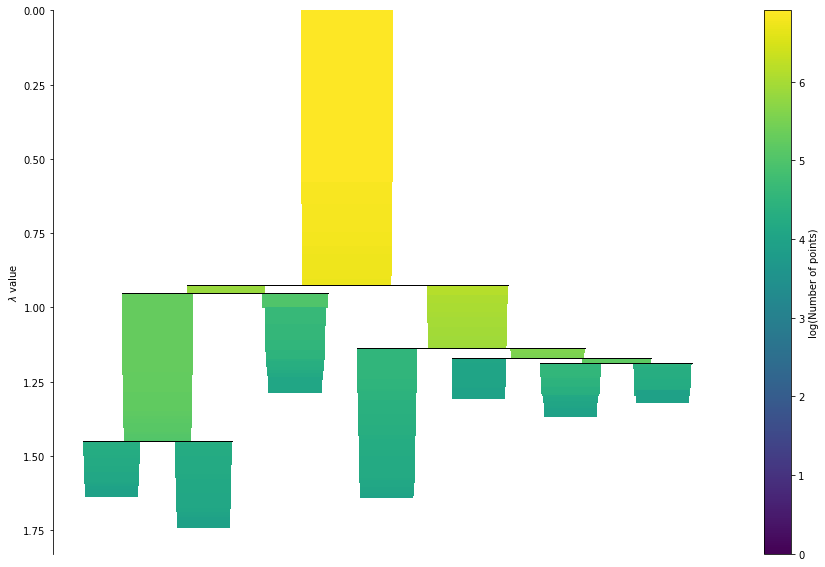

In [ ]:
plt.figure(figsize=(15,10))
hdb.get_model().condensed_tree_.plot(select_clusters=False, log_size=True)

In [ ]:
pd.Series(hdb.get_model().labels_).value_counts().sort_index()

-1    194
 0    461
 1    195
 2    150
Name: count, dtype: int64

In [ ]:
df['labels'] = hdb.get_model().labels_

ValueError: Length of values (1000) does not match length of index (85659)

In [ ]:
pd.set_option('display.max_rows', None)

In [ ]:
eth = df.groupby(['labels', 'Eth7'])['Eth7'].count()

In [ ]:
hh_liv = df.groupby(['labels', 'HHLiv9'])['HHLiv9'].count()

In [ ]:
workstat = df.groupby(['labels', 'WorkStat8'])['WorkStat8'].count()

In [ ]:
print(eth)

labels  Eth7
-1      0        3826
        1        1227
        2        1931
        3        1178
        4         146
        5         354
        6         279
 0      0       38247
        1       10691
        2        7130
        3        3597
        4        1503
        5        2240
        6        1632
 1      0         538
 2      0         203
        1          12
        2         334
        4           1
 3      0         629
        3           1
        5           3
 4      0         666
        1         242
        3         439
        4          20
        5          87
        6          86
 5      0         521
        1           2
        2           3
        3           4
        4          12
        5           1
        6          11
 6      0          15
        1        1138
        2           4
        3           2
        5           3
        6           1
 7      0          14
        1          17
        2         469
        3          

In [ ]:
print(hh_liv)

labels  HHLiv9
-1      0             1
        1             4
        2           964
        4          7334
        5            20
        6           367
        7            10
        8           241
 0      0         18759
        1          5165
        2          1947
        3         23521
        4            35
        5          5534
        6           626
        7          6455
        8          2998
 1      2           538
 2      2           538
        8            12
 3      1             2
        4           593
        6            21
        7             1
        8            16
 4      1             5
        2          1467
        5             9
        6            24
        8            35
 5      4           553
        6             1
 6      2             7
        4          1139
        6             6
        8            11
 7      4           508
 8      4          1112
        6             3
        8             5
 9      4          1545
 

In [ ]:
print(workstat)

labels  WorkStat8
-1      0             4366
        1             2301
        2              357
        3               53
        4             1337
        5              102
        6               96
        7              329
 0      0            31838
        1             7597
        2             2736
        3            14158
        4              823
        5             1410
        6             4620
        7             1858
 1      0              538
 2      0              327
        1              116
        2               27
        3                9
        4               48
        5                3
        6                4
        7               16
 3      3                1
        4              624
        6                8
 4      1              979
        2              189
        3               12
        4              249
        5               13
        6               33
        7               65
 5      0              174
        1 

In [ ]:
cluster_profiles = df.groupby('labels').agg({
    'Disab2_POP' : 'mean',
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'Educ6' : 'mean',
    'IMD10' : 'mean',
    'Motiva_POP' : 'mean',
    'motivd_POP' : 'mean',
})

<Axes: >

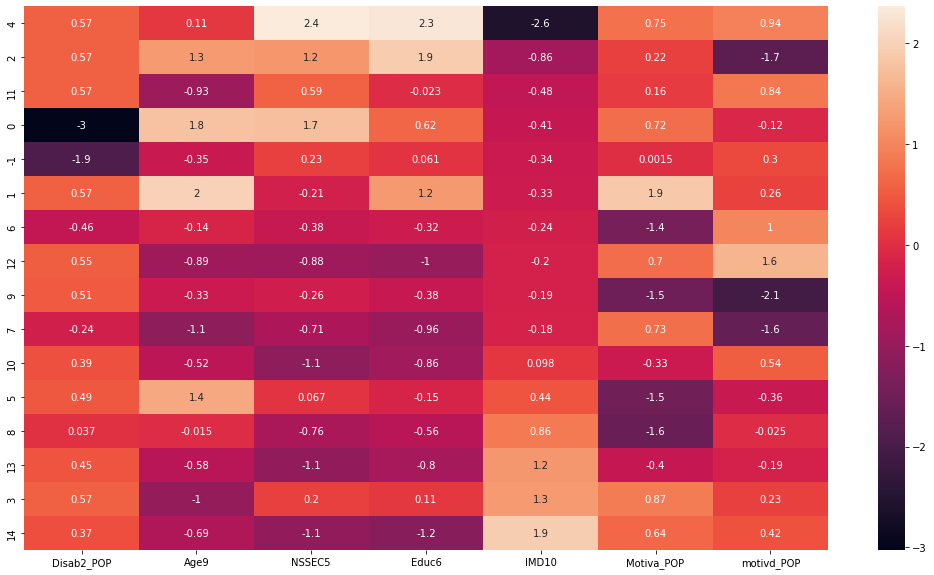

In [ ]:
scaler = StandardScaler()
sorted_cluster_profiles = cluster_profiles.sort_values('IMD10')
heat = scaler.fit_transform(sorted_cluster_profiles)
plt.figure(figsize=(18,10))
sns.heatmap(
    heat, 
    annot=True,
    xticklabels = sorted_cluster_profiles.columns,
    yticklabels = sorted_cluster_profiles.index
)

labels  Eth7
-1      0          0
        1       1227
        2       3862
        3       3534
        4        584
                ... 
 14     2        116
        3         15
        4         36
        5         35
        6         42
Name: Eth7, Length: 88, dtype: int64

In [ ]:
hdb.get_model().probabilities_

array([1., 1., 1., ..., 1., 1., 0.], shape=(85659,))

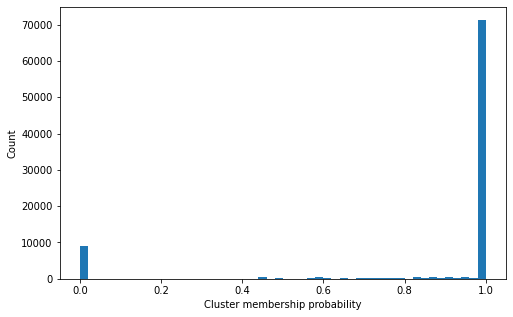

In [ ]:
probs = hdb.get_model().probabilities_
plt.figure(figsize=(8,5))
plt.hist(probs, bins=50)
plt.xlabel('Cluster membership probability')
plt.ylabel('Count')
plt.show()